In [40]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [5]:
df = pd.read_csv('sample_imdb_movies_with_adult.csv')
df['label'] = (df['averageRating'] >= 7.0).astype(int)
df['cleanTitle'] = df['primaryTitle'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

In [7]:
df['genres'] = df['genres'].fillna('').apply(lambda x: x.split(',') if x else [])

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genres'])

# Turn it into a DataFrame
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

# Merge back
df = pd.concat([df, genre_df], axis=1)


In [9]:
numeric_cols = ['startYear', 'runtimeMinutes', 'numVotes']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
results=[]

In [11]:
class ManualLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return np.where(y_predicted >= 0.5, 1, 0)


Fold 1


C:\Users\bfire\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Manual Logistic Regression Results:
Accuracy: 0.6862
Precision: 0.6700537955768081
Recall: 0.16376917457998538
F1 Score: 0.26320732566330124
ROC AUC Score: 0.560903971554531

Confusion Matrix:
[[12603   552]
 [ 5724  1121]]


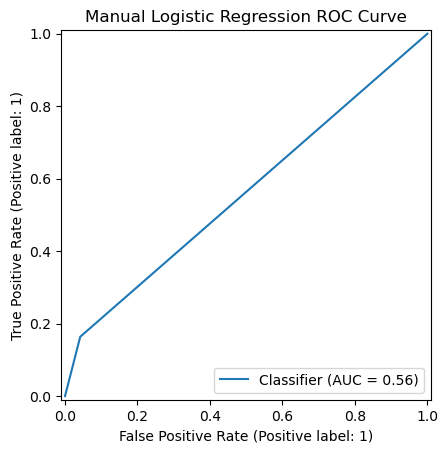


Sklearn Logistic Regression Results (with GridSearch):
Best Params: {'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Accuracy: 0.7314
Precision: 0.6570697376839412
Recall: 0.4501095690284879
F1 Score: 0.5342465753424658
ROC AUC Score: 0.6639373386761597

Confusion Matrix:
[[11547  1608]
 [ 3764  3081]]


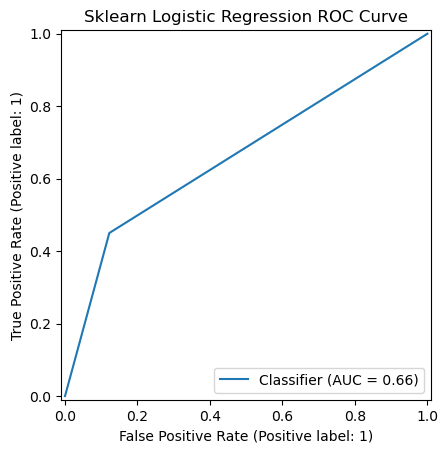

----------------------------------------
Fold 2
Manual Logistic Regression Results:
Accuracy: 0.68635
Precision: 0.6668611435239207
Recall: 0.16698319941563186
F1 Score: 0.26708727655099895
ROC AUC Score: 0.5617888250974017

Confusion Matrix:
[[12584   571]
 [ 5702  1143]]


C:\Users\bfire\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


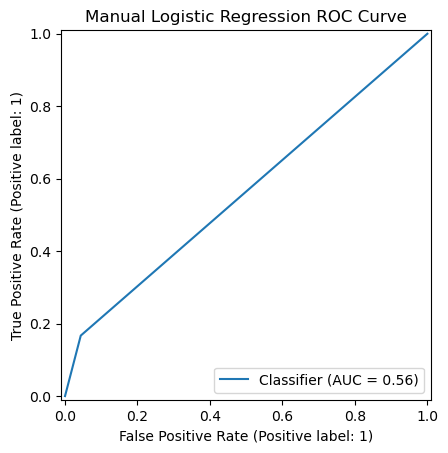


Sklearn Logistic Regression Results (with GridSearch):
Best Params: {'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 100, 'penalty': 'elasticnet', 'solver': 'saga'}
Accuracy: 0.7333
Precision: 0.6586851501785339
Recall: 0.4581446311176041
F1 Score: 0.5404101326899879
ROC AUC Score: 0.6673087275694444

Confusion Matrix:
[[11530  1625]
 [ 3709  3136]]


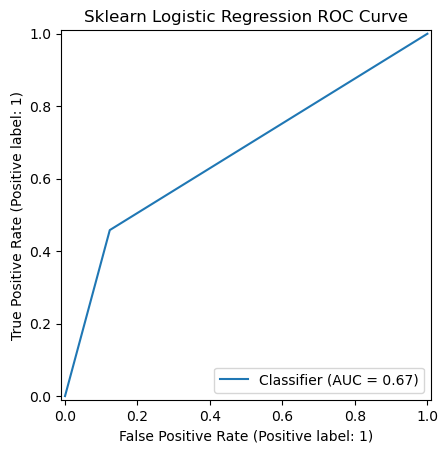

----------------------------------------
Fold 3
Manual Logistic Regression Results:
Accuracy: 0.68755
Precision: 0.673244341265235
Recall: 0.16944200993280747
F1 Score: 0.27074337729023223
ROC AUC Score: 0.5633206704673921

Confusion Matrix:
[[12591   563]
 [ 5686  1160]]


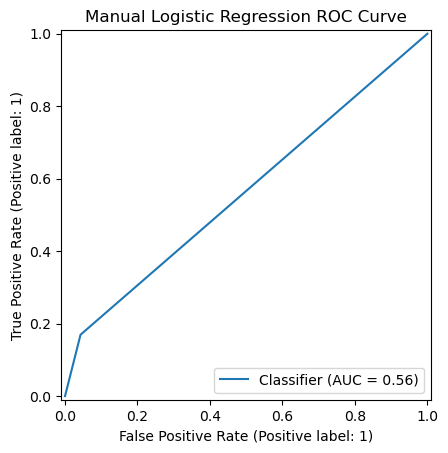


Sklearn Logistic Regression Results (with GridSearch):
Best Params: {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.73085
Precision: 0.6525547445255474
Recall: 0.4570552147239264
F1 Score: 0.5375826819001804
ROC AUC Score: 0.6652008626455271

Confusion Matrix:
[[11488  1666]
 [ 3717  3129]]


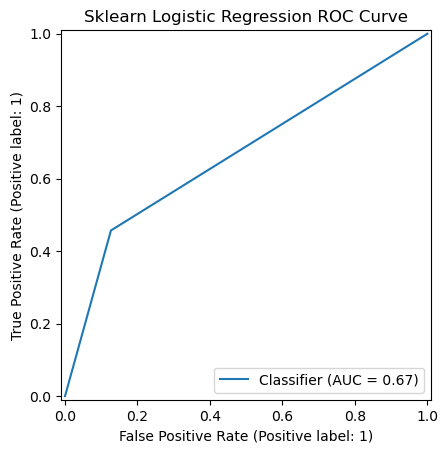

----------------------------------------
Fold 4


C:\Users\bfire\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Manual Logistic Regression Results:
Accuracy: 0.6853
Precision: 0.6584385763490241
Recall: 0.1675430908559743
F1 Score: 0.26711690731252913
ROC AUC Score: 0.5611548508864028

Confusion Matrix:
[[12559   595]
 [ 5699  1147]]


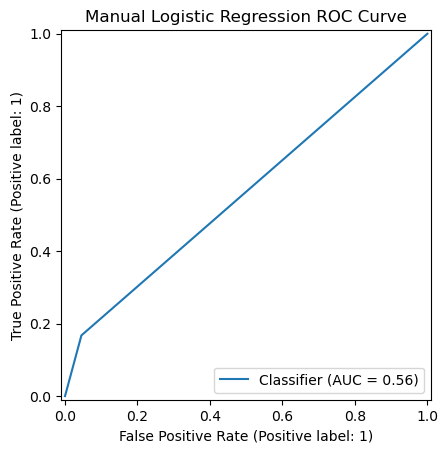


Sklearn Logistic Regression Results (with GridSearch):
Best Params: {'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Accuracy: 0.7326
Precision: 0.6555878687162443
Recall: 0.4609991235758107
F1 Score: 0.5413379073756432
ROC AUC Score: 0.6674769070821124

Confusion Matrix:
[[11496  1658]
 [ 3690  3156]]


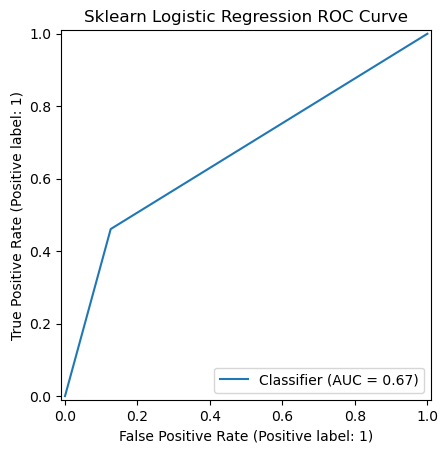

----------------------------------------
Fold 5


C:\Users\bfire\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Manual Logistic Regression Results:
Accuracy: 0.68285
Precision: 0.6428165814877911
Recall: 0.16535203038270524
F1 Score: 0.26304171023585454
ROC AUC Score: 0.5587669381045349

Confusion Matrix:
[[12525   629]
 [ 5714  1132]]


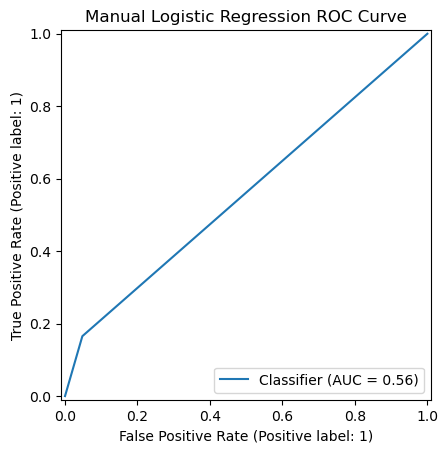


Sklearn Logistic Regression Results (with GridSearch):
Best Params: {'C': 0.01, 'l1_ratio': 0.5, 'max_iter': 100, 'penalty': 'elasticnet', 'solver': 'saga'}
Accuracy: 0.73115
Precision: 0.6515995872033024
Recall: 0.4611451942740286
F1 Score: 0.5400735608587802
ROC AUC Score: 0.6664096048913096

Confusion Matrix:
[[11466  1688]
 [ 3689  3157]]


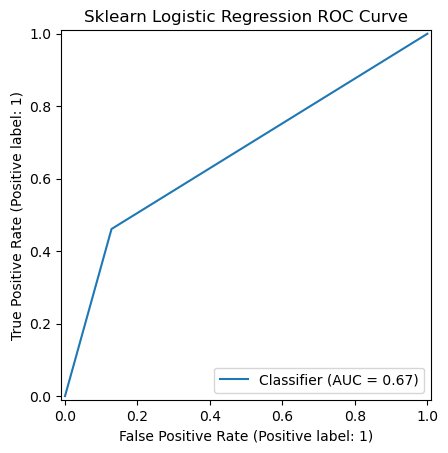

----------------------------------------


In [13]:
feature_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'isAdult'] + list(mlb.classes_)  # numeric + genres
X = df[feature_cols]
y = df['label']


results = []

# Define the valid parameter grid
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [100, 500, 1000]
    }
]

# Feature matrix and labels
feature_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'isAdult'] + list(mlb.classes_)
X = df[feature_cols]
y = df['label']

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold = 1

for train_index, test_index in kf.split(X, y):
    print(f"Fold {fold}")
    fold += 1
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fill missing values in runtime
    median_runtime = X_train['runtimeMinutes'].median()
    X_train.loc[:, 'runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    X_test.loc[:, 'runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)

    # --- Manual Logistic Regression (unchanged) ---
    X_train_np = X_train.values.astype(float)
    y_train_np = y_train.values.astype(float)

    manual_model = ManualLogisticRegression(learning_rate=0.01, num_iterations=1000)
    manual_model.fit(X_train_np, y_train_np)
    y_pred_manual = manual_model.predict(X_test.values.astype(float))

    # --- GridSearchCV for Sklearn Logistic Regression ---
    base_model = SklearnLogisticRegression()
    grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred_sklearn = best_model.predict(X_test)

    # --- Evaluation: Manual Model ---
    print("Manual Logistic Regression Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred_manual))
    print("Precision:", precision_score(y_test, y_pred_manual))
    print("Recall:", recall_score(y_test, y_pred_manual))
    print("F1 Score:", f1_score(y_test, y_pred_manual))
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_manual))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_manual))
    RocCurveDisplay.from_predictions(y_test, y_pred_manual)
    plt.title('Manual Logistic Regression ROC Curve')
    plt.show()

    # --- Evaluation: Sklearn with GridSearch ---
    print("\nSklearn Logistic Regression Results (with GridSearch):")
    print("Best Params:", grid_search.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
    print("Precision:", precision_score(y_test, y_pred_sklearn))
    print("Recall:", recall_score(y_test, y_pred_sklearn))
    print("F1 Score:", f1_score(y_test, y_pred_sklearn))
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_sklearn))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_sklearn))
    RocCurveDisplay.from_predictions(y_test, y_pred_sklearn)
    plt.title('Sklearn Logistic Regression ROC Curve')
    plt.show()

    # Append results
    results.append({
        'Model': 'Manual Regression',
        'Accuracy': accuracy_score(y_test, y_pred_manual),
        'Precision': precision_score(y_test, y_pred_manual),
        'Recall': recall_score(y_test, y_pred_manual),
        'F1 Score': f1_score(y_test, y_pred_manual)
    })
    results.append({
        'Model': 'Sklearn Regression (GridSearch)',
        'Accuracy': accuracy_score(y_test, y_pred_sklearn),
        'Precision': precision_score(y_test, y_pred_sklearn),
        'Recall': recall_score(y_test, y_pred_sklearn),
        'F1 Score': f1_score(y_test, y_pred_sklearn)
    })
    print("-" * 40)

In [151]:
class ManualDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def gini(self, y):
        classes = np.unique(y)
        impurity = 1.0
        for cls in classes:
            p = np.sum(y == cls) / len(y)
            impurity -= p ** 2
        return impurity

    def best_split(self, X, y):
        best_gini = 1
        best_idx = None
        best_threshold = None
        n_features = X.shape[1]

        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                    continue

                gini_left = self.gini(y[left_mask])
                gini_right = self.gini(y[right_mask])
                weighted_gini = (len(y[left_mask]) * gini_left + len(y[right_mask]) * gini_right) / len(y)

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_idx = feature_idx
                    best_threshold = threshold

        return best_idx, best_threshold

    def build_tree(self, X, y, depth=0):
        if (len(np.unique(y)) == 1) or (depth >= self.max_depth) or (len(y) < self.min_samples_split):
            return np.bincount(y).argmax()

        feature_idx, threshold = self.best_split(X, y)
        if feature_idx is None:
            return np.bincount(y).argmax()

        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask

        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return (feature_idx, threshold, left_subtree, right_subtree)

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.tree = self.build_tree(X, y)

    def predict_one(self, x, node):
        if not isinstance(node, tuple):
            return node
        feature_idx, threshold, left, right = node
        if x[feature_idx] <= threshold:
            return self.predict_one(x, left)
        else:
            return self.predict_one(x, right)

    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_one(x, self.tree) for x in X])

In [153]:

sklearn_tree = DecisionTreeClassifier(max_depth=5)
manual_tree = ManualDecisionTree(max_depth=5)
fold=1
for train_idx, test_idx in kf.split(X, y):
    fold+=1
    manual_scores = []
    sklearn_scores = []
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    median_runtime = X_train['runtimeMinutes'].median()
    #X_train['runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    #X_test['runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train.loc[:, 'runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    X_test.loc[:, 'runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train_np = X_train.values.astype(float)
    y_train_np = y_train.values.astype(float)

    # Train manual tree
    manual_tree.fit(X_train.values, y_train.values)
    y_pred_manual = manual_tree.predict(X_test.values)

    # Train sklearn tree
    sklearn_tree.fit(X_train, y_train)
    y_pred_sklearn = sklearn_tree.predict(X_test)

    # Evaluation
    print("\nManual Decision Tree:")
    print("Accuracy:", accuracy_score(y_test, y_pred_manual))
    print("Precision:", precision_score(y_test, y_pred_manual))
    print("Recall:", recall_score(y_test, y_pred_manual))
    print("F1 Score:", f1_score(y_test, y_pred_manual))

    print("\nScikit-learn Decision Tree:")
    print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
    print("Precision:", precision_score(y_test, y_pred_sklearn))
    print("Recall:", recall_score(y_test, y_pred_sklearn))
    print("F1 Score:", f1_score(y_test, y_pred_sklearn))

    results.append({
        'Model': 'Manual Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_manual),
        'Precision': precision_score(y_test, y_pred_manual),
        'Recall': recall_score(y_test, y_pred_manual),
        'F1 Score': f1_score(y_test, y_pred_manual)
    })
    
    results.append({
        'Model': 'Sklearn Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_sklearn),
        'Precision': precision_score(y_test, y_pred_sklearn),
        'Recall': recall_score(y_test, y_pred_sklearn),
        'F1 Score': f1_score(y_test, y_pred_sklearn)
    })
    print("-"*30)


Manual Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.5086181711948583
F1 Score: 0.5635672088694667

Scikit-learn Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.5086181711948583
F1 Score: 0.5635672088694667

Manual Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.5086181711948583
F1 Score: 0.5635672088694667

Scikit-learn Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.5086181711948583
F1 Score: 0.5635672088694667

Manual Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.5086181711948583
F1 Score: 0.5635672088694667

Scikit-learn Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.5086181711948583
F1 Score: 0.5635672088694667

Manual Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.5086181711948583
F1 Score: 0.5635672088694667

Scikit-learn Decision Tree:
Accuracy: 0.73035
Precision: 0.6318272545817456
Recall: 0.508618

In [87]:
class ManualKNN:
    def __init__(self, k=5):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict_one(self, x):
        distances = np.linalg.norm(self.X_train - x, axis=1)  # Euclidean distance
        k_indices = distances.argsort()[:self.k]  # Indices of k nearest neighbors
        k_nearest_labels = self.y_train[k_indices]
        majority_vote = Counter(k_nearest_labels).most_common(1)[0][0]
        return majority_vote

    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_one(x) for x in X])

In [157]:
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
manual_knn = ManualKNN(k=5)
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
fold=1
for train_idx, test_idx in kf.split(X,y):
    print("Fold "+fold)
    fold+=1
    manual_scores = []
    sklearn_scores = []
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    median_runtime = X_train['runtimeMinutes'].median()
    #X_train['runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    #X_test['runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train.loc[:, 'runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    X_test.loc[:, 'runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train_np = X_train.values.astype(float)
    y_train_np = y_train.values.astype(float)
    
    # Manual KNN
    manual_knn.fit(X_train.values, y_train.values)
    y_pred_manual = manual_knn.predict(X_test.values)

    # Sklearn KNN
    sklearn_knn.fit(X_train, y_train)
    y_pred_sklearn = sklearn_knn.predict(X_test)

    # Evaluation
    print("\nManual KNN:")
    print("Accuracy:", accuracy_score(y_test, y_pred_manual))
    print("Precision:", precision_score(y_test, y_pred_manual))
    print("Recall:", recall_score(y_test, y_pred_manual))
    print("F1 Score:", f1_score(y_test, y_pred_manual))

    print("\nScikit-learn KNN:")
    print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
    print("Precision:", precision_score(y_test, y_pred_sklearn))
    print("Recall:", recall_score(y_test, y_pred_sklearn))
    print("F1 Score:", f1_score(y_test, y_pred_sklearn))

    results.append({
        'Model': 'Manual KNN',
        'Accuracy': accuracy_score(y_test, y_pred_manual),
        'Precision': precision_score(y_test, y_pred_manual),
        'Recall': recall_score(y_test, y_pred_manual),
        'F1 Score': f1_score(y_test, y_pred_manual)
    })
    
    # After evaluating sklearn Naive Bayes
    results.append({
        'Model': 'Sklearn KNN',
        'Accuracy': accuracy_score(y_test, y_pred_sklearn),
        'Precision': precision_score(y_test, y_pred_sklearn),
        'Recall': recall_score(y_test, y_pred_sklearn),
        'F1 Score': f1_score(y_test, y_pred_sklearn)
    })
    print("-"*30)


1

Manual KNN:
Accuracy: 0.69925
Precision: 0.5717492661025729
Recall: 0.483640081799591
F1 Score: 0.524016776133576

Scikit-learn KNN:
Accuracy: 0.6994
Precision: 0.5720705150362945
Recall: 0.4834940111013731
F1 Score: 0.5240658644711843
------------------------------
2

Manual KNN:
Accuracy: 0.69925
Precision: 0.5717492661025729
Recall: 0.483640081799591
F1 Score: 0.524016776133576

Scikit-learn KNN:
Accuracy: 0.6994
Precision: 0.5720705150362945
Recall: 0.4834940111013731
F1 Score: 0.5240658644711843
------------------------------
3

Manual KNN:
Accuracy: 0.69925
Precision: 0.5717492661025729
Recall: 0.483640081799591
F1 Score: 0.524016776133576

Scikit-learn KNN:
Accuracy: 0.6994
Precision: 0.5720705150362945
Recall: 0.4834940111013731
F1 Score: 0.5240658644711843
------------------------------
4

Manual KNN:
Accuracy: 0.69925
Precision: 0.5717492661025729
Recall: 0.483640081799591
F1 Score: 0.524016776133576

Scikit-learn KNN:
Accuracy: 0.6994
Precision: 0.5720705150362945
Recall:

In [159]:
class ManualGaussianNB:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means = {}
        self.vars = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.vars[c] = np.var(X_c, axis=0) + 1e-6  # add small value to prevent division by zero
            self.priors[c] = X_c.shape[0] / X.shape[0]

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        posteriors = []

        for c in self.classes:
            prior = np.log(self.priors[c])
            class_conditional = np.sum(self._gaussian_log_likelihood(c, x))
            posterior = prior + class_conditional
            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]

    def _gaussian_log_likelihood(self, class_idx, x):
        mean = self.means[class_idx]
        var = self.vars[class_idx]
        return -0.5 * np.log(2 * np.pi * var) - ((x - mean)**2) / (2 * var)

In [161]:
sklearn_nb = GaussianNB()
manual_nb = ManualGaussianNB()
sklearn_nb = GaussianNB()
fold=1
for train_idx, test_idx in kf.split(X,y):
    fold+=1
    manual_scores = []
    sklearn_scores = []
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    median_runtime = X_train['runtimeMinutes'].median()
    #X_train['runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    #X_test['runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train.loc[:, 'runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    X_test.loc[:, 'runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train_np = X_train.values.astype(float)
    y_train_np = y_train.values.astype(float)

    # Manual Naive Bayes
    manual_nb.fit(X_train.values, y_train.values)
    y_pred_manual = manual_nb.predict(X_test.values)

    # Sklearn Naive Bayes
    sklearn_nb.fit(X_train, y_train)
    y_pred_sklearn = sklearn_nb.predict(X_test)

    # Evaluation
    print("\nManual Naive Bayes:")
    print("Accuracy:", accuracy_score(y_test, y_pred_manual))
    print("Precision:", precision_score(y_test, y_pred_manual))
    print("Recall:", recall_score(y_test, y_pred_manual))
    print("F1 Score:", f1_score(y_test, y_pred_manual))

    print("\nScikit-learn Naive Bayes:")
    print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
    print("Precision:", precision_score(y_test, y_pred_sklearn))
    print("Recall:", recall_score(y_test, y_pred_sklearn))
    print("F1 Score:", f1_score(y_test, y_pred_sklearn))

    results.append({
        'Model': 'Manual Naive Bayes',
        'Accuracy': accuracy_score(y_test, y_pred_manual),
        'Precision': precision_score(y_test, y_pred_manual),
        'Recall': recall_score(y_test, y_pred_manual),
        'F1 Score': f1_score(y_test, y_pred_manual)
    })
    
    # After evaluating sklearn Naive Bayes
    results.append({
        'Model': 'Sklearn Naive Bayes',
        'Accuracy': accuracy_score(y_test, y_pred_sklearn),
        'Precision': precision_score(y_test, y_pred_sklearn),
        'Recall': recall_score(y_test, y_pred_sklearn),
        'F1 Score': f1_score(y_test, y_pred_sklearn)
    })



Manual Naive Bayes:
Accuracy: 0.70845
Precision: 0.5867373098615621
Recall: 0.5014607069821794
F1 Score: 0.540757659289596

Scikit-learn Naive Bayes:
Accuracy: 0.6631
Precision: 0.5224066390041494
Recall: 0.1839030090563833
F1 Score: 0.27203975799481417

Manual Naive Bayes:
Accuracy: 0.70845
Precision: 0.5867373098615621
Recall: 0.5014607069821794
F1 Score: 0.540757659289596

Scikit-learn Naive Bayes:
Accuracy: 0.6631
Precision: 0.5224066390041494
Recall: 0.1839030090563833
F1 Score: 0.27203975799481417

Manual Naive Bayes:
Accuracy: 0.70845
Precision: 0.5867373098615621
Recall: 0.5014607069821794
F1 Score: 0.540757659289596

Scikit-learn Naive Bayes:
Accuracy: 0.6631
Precision: 0.5224066390041494
Recall: 0.1839030090563833
F1 Score: 0.27203975799481417

Manual Naive Bayes:
Accuracy: 0.70845
Precision: 0.5867373098615621
Recall: 0.5014607069821794
F1 Score: 0.540757659289596

Scikit-learn Naive Bayes:
Accuracy: 0.6631
Precision: 0.5224066390041494
Recall: 0.1839030090563833
F1 Score: 

In [163]:
def build_neural_network(input_dim):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
    ])

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    )

    return model

In [169]:

    manual_scores = []
    sklearn_scores = []
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    median_runtime = X_train['runtimeMinutes'].median()
    #X_train['runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    #X_test['runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train.loc[:, 'runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    X_test.loc[:, 'runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)
    X_train_np = X_train.values.astype(float)
    y_train_np = y_train.values.astype(float)

    input_dim = X_train.shape[1]
    
    # Build the model
    nn_model = build_neural_network(input_dim)
    
    # Train the model
    history = nn_model.fit(
        X_train, y_train,
        epochs=20,       # You can tune this
        batch_size=32,   # You can tune this
        validation_data=(X_test, y_test),
        verbose=1
    )
    # Evaluate on test set
    nn_eval = nn_model.evaluate(X_test, y_test, verbose=0)
    
    # Get predictions
    y_pred_nn = (nn_model.predict(X_test) > 0.5).astype(int)
    
    # Calculate more metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_test, y_pred_nn)
    precision = precision_score(y_test, y_pred_nn)
    recall = recall_score(y_test, y_pred_nn)
    f1 = f1_score(y_test, y_pred_nn)
    
    print(f"Neural Network Test Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    results.append({
        'Model': 'Nueral Network',
        'Accuracy': accuracy_score(y_test, y_pred_nn),
        'Precision': precision_score(y_test, y_pred_nn),
        'Recall': recall_score(y_test, y_pred_nn),
        'F1 Score': f1_score(y_test, y_pred_nn)
    })


C:\Users\bfire\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.7158 - loss: 0.5724 - precision_9: 0.6297 - recall_9: 0.3984 - val_accuracy: 0.7339 - val_loss: 0.5518 - val_precision_9: 0.6509 - val_recall_9: 0.4797
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7369 - loss: 0.5483 - precision_9: 0.6496 - recall_9: 0.4901 - val_accuracy: 0.7347 - val_loss: 0.5473 - val_precision_9: 0.6487 - val_recall_9: 0.4909
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7375 - loss: 0.5458 - precision_9: 0.6508 - recall_9: 0.4914 - val_accuracy: 0.7353 - val_loss: 0.5462 - val_precision_9: 0.6427 - val_recall_9: 0.5105
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7391 - loss: 0.5436 - precision_9: 0.6530 - recall_9: 0.5009 - val_accuracy: 0.7347 - val_loss: 0.5478 - val_precision_9: 0.6328 - val_recall_9: 0.5361
Epoch 5/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7392 - loss: 0.5417 - precision_9: 0.6546 - rec

In [167]:
results_df = pd.DataFrame(results)
results_df.to_excel("model_comparison_results_2.xlsx", index=False)

In [54]:
from sklearn.utils.class_weight import compute_class_weight

fold = 1
results = []
use_smote = False  # Set to True to try SMOTE resampling

for train_idx, test_idx in kf.split(X, y):
    print(f"\nFold {fold}")
    fold += 1
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

    # Handle missing runtime
    median_runtime = X_train['runtimeMinutes'].median()
    X_train['runtimeMinutes'] = X_train['runtimeMinutes'].fillna(median_runtime)
    X_test['runtimeMinutes'] = X_test['runtimeMinutes'].fillna(median_runtime)

    # Log-transform skewed features
    for col in ['num_votes', 'revenue']:
        if col in X_train.columns:
            X_train[col] = np.log1p(X_train[col])
            X_test[col] = np.log1p(X_test[col])

    # Compute class weights for current fold
    class_weights_array = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train)
    class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}

    # Optional SMOTE
    if use_smote:
        smote = SMOTE()
        X_train, y_train = smote.fit_resample(X_train, y_train)

    # --- Decision Tree with Class Weight ---
    sklearn_tree = GridSearchCV(
        DecisionTreeClassifier(class_weight=class_weight_dict),
        tree_params,
        cv=3,
        scoring='accuracy'
    )
    sklearn_tree.fit(X_train, y_train)
    y_pred_tree = sklearn_tree.predict(X_test)

    acc = accuracy_score(y_test, y_pred_tree)
    prec = precision_score(y_test, y_pred_tree)
    rec = recall_score(y_test, y_pred_tree)
    f1 = f1_score(y_test, y_pred_tree)

    print("Best Decision Tree Params:", sklearn_tree.best_params_)
    print(f"Decision Tree - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    print(confusion_matrix(y_test, y_pred_tree))
    print(classification_report(y_test, y_pred_tree))

    results.append({'Model': 'Sklearn Decision Tree', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1})

    # --- KNN with Scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    sklearn_knn = GridSearchCV(
        KNeighborsClassifier(),
        knn_params,
        cv=3,
        scoring='accuracy'
    )
    sklearn_knn.fit(X_train_scaled, y_train)
    y_pred_knn = sklearn_knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_knn)
    prec = precision_score(y_test, y_pred_knn)
    rec = recall_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)

    print("Best KNN Params:", sklearn_knn.best_params_)
    print(f"KNN - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    print(confusion_matrix(y_test, y_pred_knn))
    print(classification_report(y_test, y_pred_knn))

    results.append({'Model': 'Sklearn KNN', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1})

    # --- Naive Bayes ---
    sklearn_nb = GaussianNB()
    sklearn_nb.fit(X_train, y_train)
    y_pred_nb = sklearn_nb.predict(X_test)

    acc = accuracy_score(y_test, y_pred_nb)
    prec = precision_score(y_test, y_pred_nb)
    rec = recall_score(y_test, y_pred_nb)
    f1 = f1_score(y_test, y_pred_nb)

    print(f"Naive Bayes - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    print(confusion_matrix(y_test, y_pred_nb))
    print(classification_report(y_test, y_pred_nb))

    results.append({'Model': 'Sklearn Naive Bayes', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1})

    # --- Neural Network with Class Weights ---
    input_dim = X_train.shape[1]
    for layers_config in nn_param_grid['hidden_layers']:
        for batch_size in nn_param_grid['batch_size']:
            for epochs in nn_param_grid['epochs']:
                model = keras.Sequential()
                model.add(layers.InputLayer(input_shape=(input_dim,)))
                for units in layers_config:
                    model.add(layers.Dense(units, activation='relu'))
                model.add(layers.Dense(1, activation='sigmoid'))

                model.compile(
                    optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
                )

                history = model.fit(
                    X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    verbose=0,
                    class_weight=class_weight_dict
                )

                y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

                acc = accuracy_score(y_test, y_pred_nn)
                prec = precision_score(y_test, y_pred_nn)
                rec = recall_score(y_test, y_pred_nn)
                f1 = f1_score(y_test, y_pred_nn)

                print(f"Neural Net {layers_config}, batch={batch_size}, epochs={epochs}")
                print(f"Neural Network - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
                print(confusion_matrix(y_test, y_pred_nn))
                print(classification_report(y_test, y_pred_nn))

                results.append({
                    'Model': f'Neural Net {layers_config}, batch={batch_size}',
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                    'F1 Score': f1
                })



Fold 1
Best Decision Tree Params: {'max_depth': 10, 'min_samples_split': 5}
Decision Tree - Acc: 0.7087, Prec: 0.5560, Rec: 0.7394, F1: 0.6347
[[9114 4041]
 [1784 5061]]
              precision    recall  f1-score   support

           0       0.84      0.69      0.76     13155
           1       0.56      0.74      0.63      6845

    accuracy                           0.71     20000
   macro avg       0.70      0.72      0.70     20000
weighted avg       0.74      0.71      0.72     20000

Best KNN Params: {'n_neighbors': 7, 'weights': 'uniform'}
KNN - Acc: 0.7107, Prec: 0.5976, Rec: 0.4736, F1: 0.5284
[[10972  2183]
 [ 3603  3242]]
              precision    recall  f1-score   support

           0       0.75      0.83      0.79     13155
           1       0.60      0.47      0.53      6845

    accuracy                           0.71     20000
   macro avg       0.68      0.65      0.66     20000
weighted avg       0.70      0.71      0.70     20000

Naive Bayes - Acc: 0.6634, Pr

C:\Users\bfire\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Neural Net [64], batch=32, epochs=10
Neural Network - Acc: 0.7091, Prec: 0.5678, Rec: 0.6286, F1: 0.5967
[[9880 3275]
 [2542 4303]]
              precision    recall  f1-score   support

           0       0.80      0.75      0.77     13155
           1       0.57      0.63      0.60      6845

    accuracy                           0.71     20000
   macro avg       0.68      0.69      0.68     20000
weighted avg       0.72      0.71      0.71     20000



C:\Users\bfire\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Neural Net [64], batch=32, epochs=20
Neural Network - Acc: 0.7230, Prec: 0.5943, Rec: 0.6012, F1: 0.5977
[[10346  2809]
 [ 2730  4115]]
              precision    recall  f1-score   support

           0       0.79      0.79      0.79     13155
           1       0.59      0.60      0.60      6845

    accuracy                           0.72     20000
   macro avg       0.69      0.69      0.69     20000
weighted avg       0.72      0.72      0.72     20000



C:\Users\bfire\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Neural Net [64], batch=64, epochs=10
Neural Network - Acc: 0.7121, Prec: 0.5743, Rec: 0.6137, F1: 0.5934
[[10041  3114]
 [ 2644  4201]]
              precision    recall  f1-score   support

           0       0.79      0.76      0.78     13155
           1       0.57      0.61      0.59      6845

    accuracy                           0.71     20000
   macro avg       0.68      0.69      0.69     20000
weighted avg       0.72      0.71      0.71     20000



C:\Users\bfire\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


KeyboardInterrupt: 

In [28]:
from collections import Counter
print(Counter(y))

Counter({0: 65772, 1: 34228})


In [32]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined